# Conditional Normalizing Flow for Throw Prediction

This notebook implements a **Conditional Normalizing Flow** to predict throw distributions.

## What are Normalizing Flows?

Normalizing flows learn a **continuous transformation** from a simple distribution (Gaussian) to a complex one:

```
z ~ N(0, I)  (simple Gaussian)
     ↓
   Flow layers (invertible transformations)
     ↓
x = f(z)  (complex distribution, e.g., throw destinations)
```

**Key advantages over GMM:**
- No fixed K components - truly continuous
- Can model arbitrary distributions
- Exact likelihood computation (no approximation)
- Can generate samples by sampling z and transforming

**Conditional flows:**
We condition the transformation on player + position:
```
x = f(z | player, position)
```

## Architecture: Masked Autoregressive Flow (MAF)

MAF uses autoregressive transformations:
- `x_1 = f_1(z_1 | context)`
- `x_2 = f_2(z_2 | context, x_1)`

Each transformation is a neural network conditioned on context (player + position).

## Setup and Installation

In [3]:
# Install normalizing flow library
# %pip install nflows

In [4]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Normalizing flows library
try:
    from nflows import flows, distributions, transforms
    from nflows.nn import nets
    print("✅ nflows library loaded")
except ImportError:
    print("❌ nflows not installed. Run: pip install nflows")

import joblib
import os

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

✅ nflows library loaded


## 1. Load Data (Same as MDN)

In [5]:
# Database connection
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': 'joemolder',
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

In [6]:
# Query all throw events
conn = get_db_connection()
cur = conn.cursor()

query = """
SELECT
    thrower as player_id,
    thrower_x,
    thrower_y,
    CASE
        WHEN event_type IN (18, 19, 20) THEN receiver_x
        WHEN event_type = 22 THEN turnover_x
    END as dest_x,
    CASE
        WHEN event_type IN (18, 19, 20) THEN receiver_y
        WHEN event_type = 22 THEN turnover_y
    END as dest_y,
    event_type
FROM events
WHERE thrower IS NOT NULL
    AND event_type IN (18, 19, 20, 22)
    AND thrower_x IS NOT NULL
    AND (
        (event_type IN (18, 19, 20) AND receiver_x IS NOT NULL)
        OR (event_type = 22 AND turnover_x IS NOT NULL)
    )
ORDER BY event_id;
"""

cur.execute(query)
rows = cur.fetchall()
cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f"Total throw events: {len(df):,}")

Total throw events: 412,114


## 2. Preprocessing

In [7]:
# Filter players with minimum throws
MIN_THROWS = 500

player_counts = df['player_id'].value_counts()
valid_players = player_counts[player_counts >= MIN_THROWS].index
df_filtered = df[df['player_id'].isin(valid_players)].copy()

print(f"Players with {MIN_THROWS}+ throws: {len(valid_players)}")
print(f"Total throws: {len(df_filtered):,}")

Players with 500+ throws: 244
Total throws: 243,773


In [8]:
# Encode players
player_encoder = LabelEncoder()
df_filtered['player_encoded'] = player_encoder.fit_transform(df_filtered['player_id'])
n_players = len(player_encoder.classes_)

print(f"Number of players: {n_players}")

Number of players: 244


In [9]:
# Normalize coordinates to [0, 1]
df_filtered['thrower_x_norm'] = (df_filtered['thrower_x'] + 25) / 50
df_filtered['thrower_y_norm'] = df_filtered['thrower_y'] / 120
df_filtered['dest_x_norm'] = (df_filtered['dest_x'] + 25) / 50
df_filtered['dest_y_norm'] = df_filtered['dest_y'] / 120

print("Coordinates normalized to [0, 1]")

Coordinates normalized to [0, 1]


In [10]:
# Create feature and target arrays
# Context: [player_id (int), thrower_x_norm, thrower_y_norm]
# Target: [dest_x_norm, dest_y_norm]

context = df_filtered[['player_encoded', 'thrower_x_norm', 'thrower_y_norm']].values
target = df_filtered[['dest_x_norm', 'dest_y_norm']].values

print(f"Context shape: {context.shape}")
print(f"Target shape: {target.shape}")

Context shape: (243773, 3)
Target shape: (243773, 2)


In [11]:
# Train/test split
context_train, context_test, target_train, target_test = train_test_split(
    context, target, test_size=0.2, random_state=42
)

print(f"Train: {len(context_train):,} samples")
print(f"Test: {len(context_test):,} samples")

Train: 195,018 samples
Test: 48,755 samples


## 3. Build Conditional Normalizing Flow

We'll use a **Masked Autoregressive Flow (MAF)** with:
- Player embeddings in the context network
- Multiple flow layers for expressiveness
- Gaussian base distribution

In [12]:
class ContextNetwork(nn.Module):
    """
    Processes context (player + position) before feeding to flow.
    Includes player embeddings.
    """
    def __init__(self, n_players, embedding_dim=16, hidden_dim=64, output_dim=32):
        super().__init__()
        
        # Player embedding
        self.player_embedding = nn.Embedding(n_players, embedding_dim)
        
        # MLP to process embeddings + position
        input_dim = embedding_dim + 2  # embedding + (x, y)
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, context):
        """
        Args:
            context: [batch, 3] - (player_id, x, y)
        Returns:
            features: [batch, output_dim]
        """
        player_ids = context[:, 0].long()
        position = context[:, 1:3]
        
        # Get embeddings
        player_emb = self.player_embedding(player_ids)
        
        # Concatenate and process
        combined = torch.cat([player_emb, position], dim=1)
        features = self.network(combined)
        
        return features

In [13]:
def create_flow(n_players, num_layers=5, hidden_features=128, context_features=32):
    """
    Create a conditional normalizing flow for 2D throw destinations.
    
    Args:
        n_players: Number of unique players
        num_layers: Number of flow transformation layers
        hidden_features: Hidden dimension for flow networks
        context_features: Dimension of processed context
    
    Returns:
        flow: nflows Flow object
        context_net: Network to process player + position
    """
    # Base distribution: 2D standard Gaussian
    base_dist = distributions.StandardNormal(shape=[2])
    
    # Context network (processes player + position)
    context_net = ContextNetwork(
        n_players=n_players,
        embedding_dim=16,
        hidden_dim=64,
        output_dim=context_features
    )
    
    # Build flow layers
    transform_list = []
    
    for _ in range(num_layers):
        # Masked Autoregressive Transform
        transform_list.append(
            transforms.MaskedAffineAutoregressiveTransform(
                features=2,  # 2D output (dest_x, dest_y)
                hidden_features=hidden_features,
                context_features=context_features,
                num_blocks=2
            )
        )
        # Reverse for alternating directions
        transform_list.append(transforms.ReversePermutation(features=2))
    
    # Composite transform
    transform = transforms.CompositeTransform(transform_list)
    
    # Create flow
    flow = flows.Flow(transform, base_dist)
    
    return flow, context_net

## 4. Training Setup

In [14]:
# Hyperparameters
NUM_LAYERS = 5          # Number of flow layers
HIDDEN_FEATURES = 128   # Hidden dimension for flow networks
CONTEXT_FEATURES = 32   # Context embedding dimension
LEARNING_RATE = 0.0005  # Lower LR for stability
WEIGHT_DECAY = 0.0001   # L2 regularization
BATCH_SIZE = 256        # Larger batches for flow training
EPOCHS = 200

print("Flow Hyperparameters:")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Hidden features: {HIDDEN_FEATURES}")
print(f"  Context features: {CONTEXT_FEATURES}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Batch size: {BATCH_SIZE}")

Flow Hyperparameters:
  Layers: 5
  Hidden features: 128
  Context features: 32
  Learning rate: 0.0005
  Weight decay: 0.0001
  Batch size: 256


In [15]:
# Create model
flow, context_net = create_flow(
    n_players=n_players,
    num_layers=NUM_LAYERS,
    hidden_features=HIDDEN_FEATURES,
    context_features=CONTEXT_FEATURES
)

# Count parameters
flow_params = sum(p.numel() for p in flow.parameters())
context_params = sum(p.numel() for p in context_net.parameters())
total_params = flow_params + context_params

print(f"\nModel Parameters:")
print(f"  Flow network: {flow_params:,}")
print(f"  Context network: {context_params:,}")
print(f"  Total: {total_params:,}")


Model Parameters:
  Flow network: 398,100
  Context network: 11,360
  Total: 409,460


In [16]:
# Create data loaders
train_dataset = TensorDataset(
    torch.FloatTensor(context_train),
    torch.FloatTensor(target_train)
)
test_dataset = TensorDataset(
    torch.FloatTensor(context_test),
    torch.FloatTensor(target_test)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 762
Test batches: 191


In [17]:
# Optimizer
optimizer = optim.Adam(
    list(flow.parameters()) + list(context_net.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=10,
    min_lr=1e-6
)

print("✅ Optimizer and scheduler created")

✅ Optimizer and scheduler created


## 5. Training Loop

In [18]:
def train_epoch(flow, context_net, train_loader, optimizer):
    """Train for one epoch."""
    flow.train()
    context_net.train()
    total_loss = 0
    
    for batch_context, batch_target in train_loader:
        optimizer.zero_grad()
        
        # Process context
        context_features = context_net(batch_context)
        
        # Compute negative log-likelihood
        log_prob = flow.log_prob(batch_target, context=context_features)
        loss = -log_prob.mean()  # Negative log-likelihood
        
        # Backward
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            list(flow.parameters()) + list(context_net.parameters()),
            max_norm=5.0
        )
        
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate(flow, context_net, test_loader):
    """Validate on test set."""
    flow.eval()
    context_net.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_context, batch_target in test_loader:
            # Process context
            context_features = context_net(batch_context)
            
            # Compute log-likelihood
            log_prob = flow.log_prob(batch_target, context=context_features)
            loss = -log_prob.mean()
            
            total_loss += loss.item()
    
    return total_loss / len(test_loader)

In [19]:
# Training loop with early stopping
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

print("Starting training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_epoch(flow, context_net, train_loader, optimizer)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(flow, context_net, test_loader)
    val_losses.append(val_loss)
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_flow_state = flow.state_dict().copy()
        best_context_state = context_net.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:6d} | {train_loss:12.4f} | {val_loss:12.4f} | {current_lr:10.6f}")
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        flow.load_state_dict(best_flow_state)
        context_net.load_state_dict(best_context_state)
        break

print("\n✅ Training complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
    10 |      -1.3451 |      -1.3512 |   0.000500
    20 |      -1.3861 |      -1.3754 |   0.000500
    30 |      -1.4088 |      -1.3975 |   0.000500
    40 |      -1.4218 |      -1.3833 |   0.000500
    50 |      -1.4369 |      -1.3998 |   0.000500
    60 |      -1.4463 |      -1.4159 |   0.000500
    70 |      -1.4660 |      -1.4235 |   0.000350
    80 |      -1.4746 |      -1.4240 |   0.000350
    90 |      -1.4814 |      -1.4217 |   0.000350
   100 |      -1.4983 |      -1.4123 |   0.000245

Early stopping at epoch 104
Best validation loss: -1.4259

✅ Training complete!
Best validation loss: -1.4259


## 6. Visualize Training

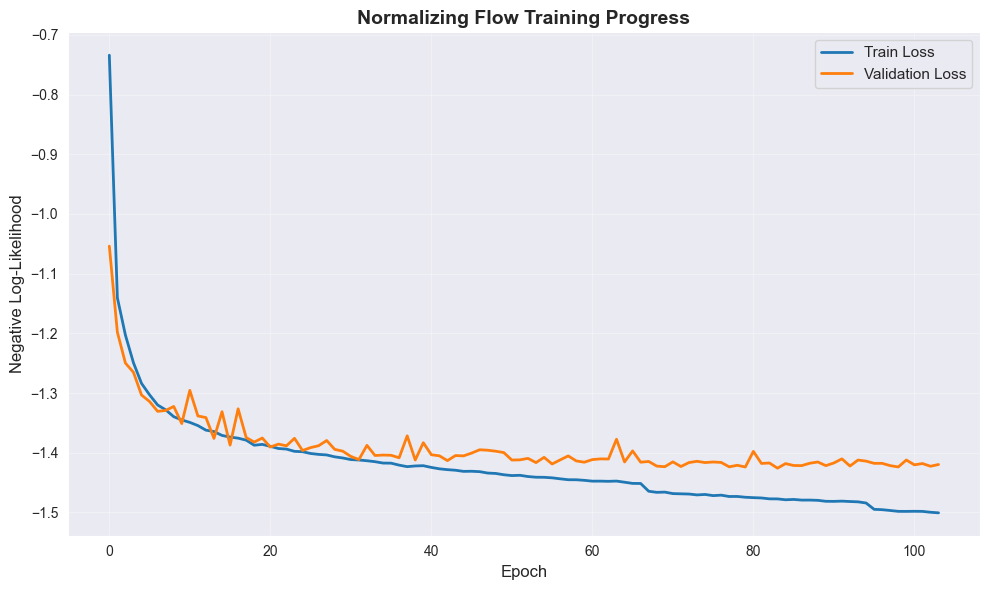

Final train loss: -1.5007
Final val loss: -1.4198
Best val loss: -1.4259


In [20]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_losses, label='Train Loss', linewidth=2)
ax.plot(val_losses, label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Negative Log-Likelihood', fontsize=12)
ax.set_title('Normalizing Flow Training Progress', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('flow_training_curve.png', dpi=150)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")

## 7. Generate Predictions

The key advantage of flows: we can compute exact probability density at any point!

In [21]:
def predict_throw_distribution_flow(flow, context_net, player_encoder, 
                                    player_name, thrower_x, thrower_y, grid_size=30):
    """
    Predict throw distribution using normalizing flow.
    
    Returns:
        grid: [grid_y, grid_x] probability density
        samples: Generated throw samples from the distribution
    """
    flow.eval()
    context_net.eval()
    
    # Encode player
    try:
        player_encoded = player_encoder.transform([player_name])[0]
    except:
        raise ValueError(f"Player '{player_name}' not in training data")
    
    # Normalize coordinates
    thrower_x_norm = (thrower_x + 25) / 50
    thrower_y_norm = thrower_y / 120
    
    # Create context tensor
    context_input = torch.FloatTensor([[player_encoded, thrower_x_norm, thrower_y_norm]])
    
    with torch.no_grad():
        # Process context
        context_features = context_net(context_input)
        
        # Create probability grid
        x_bins = np.linspace(0, 1, grid_size)
        y_bins = np.linspace(0, 1, int(grid_size * 1.2))
        
        grid = np.zeros((len(y_bins), len(x_bins)))
        
        # Compute probability for each grid point
        for i, y_norm in enumerate(y_bins):
            for j, x_norm in enumerate(x_bins):
                point = torch.FloatTensor([[x_norm, y_norm]])
                log_prob = flow.log_prob(point, context=context_features)
                grid[i, j] = torch.exp(log_prob).item()
        
        # Generate samples from the distribution
        samples = flow.sample(1000, context=context_features).numpy()
    
    return grid, samples

In [22]:
def visualize_flow_prediction(player_name, thrower_x, thrower_y):
    """Visualize flow prediction with heatmap and samples."""
    try:
        grid, samples = predict_throw_distribution_flow(
            flow, context_net, player_encoder, player_name, thrower_x, thrower_y
        )
    except ValueError as e:
        print(f"Error: {e}")
        return
    
    # Denormalize samples
    samples_denorm = samples.copy()
    samples_denorm[:, 0] = samples[:, 0] * 50 - 25  # x
    samples_denorm[:, 1] = samples[:, 1] * 120       # y
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Left: Probability density heatmap
    extent = [-25, 25, 0, 120]
    im = ax1.imshow(grid, extent=extent, origin='lower', cmap='hot', alpha=0.7)
    
    ax1.plot(thrower_x, thrower_y, 'bo', markersize=15, label='Thrower', zorder=10)
    ax1.axhline(y=20, color='white', linestyle='--', alpha=0.5, linewidth=2)
    ax1.axhline(y=100, color='white', linestyle='--', alpha=0.5, linewidth=2)
    ax1.axhline(y=60, color='white', linestyle=':', alpha=0.3, linewidth=2)
    
    ax1.set_xlim(-27, 27)
    ax1.set_ylim(0, 120)
    ax1.set_xlabel('Field X (meters)', fontsize=12)
    ax1.set_ylabel('Field Y (meters)', fontsize=12)
    ax1.set_title(f'{player_name} - Flow Density Heatmap', fontsize=13, fontweight='bold')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='Probability Density')
    
    # Right: Generated samples
    ax2.scatter(samples_denorm[:, 0], samples_denorm[:, 1], 
                alpha=0.3, s=10, c='red', label='Generated throws')
    ax2.plot(thrower_x, thrower_y, 'bo', markersize=15, label='Thrower', zorder=10)
    ax2.axhline(y=20, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    ax2.axhline(y=60, color='gray', linestyle=':', alpha=0.3, linewidth=2)
    
    ax2.set_xlim(-27, 27)
    ax2.set_ylim(0, 120)
    ax2.set_xlabel('Field X (meters)', fontsize=12)
    ax2.set_ylabel('Field Y (meters)', fontsize=12)
    ax2.set_title(f'{player_name} - Generated Samples', fontsize=13, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

Testing with: pjanas


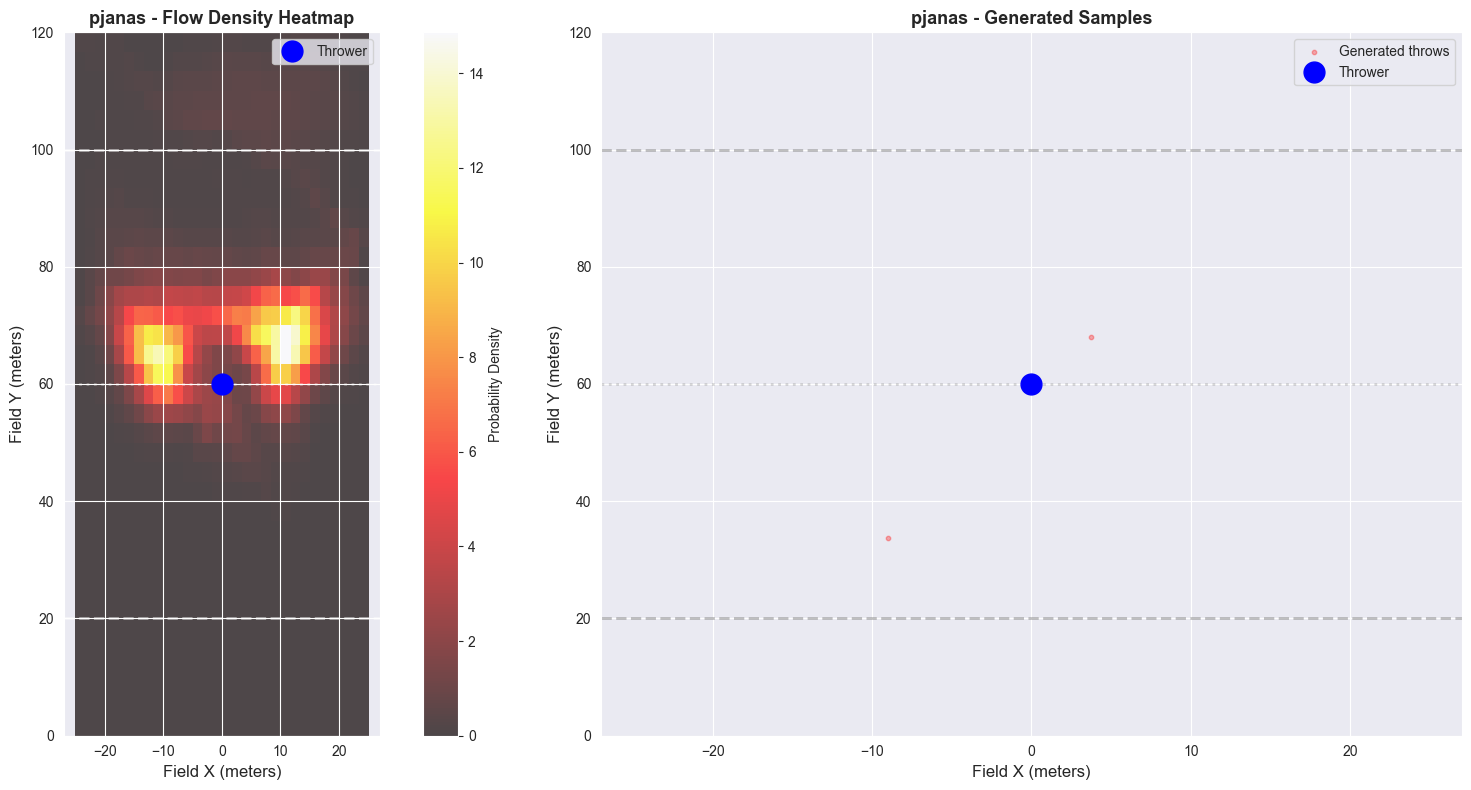

In [23]:
# Test with top player
top_player = player_counts.head(1).index[0]
print(f"Testing with: {top_player}")

# From midfield
visualize_flow_prediction(top_player, thrower_x=0, thrower_y=60)

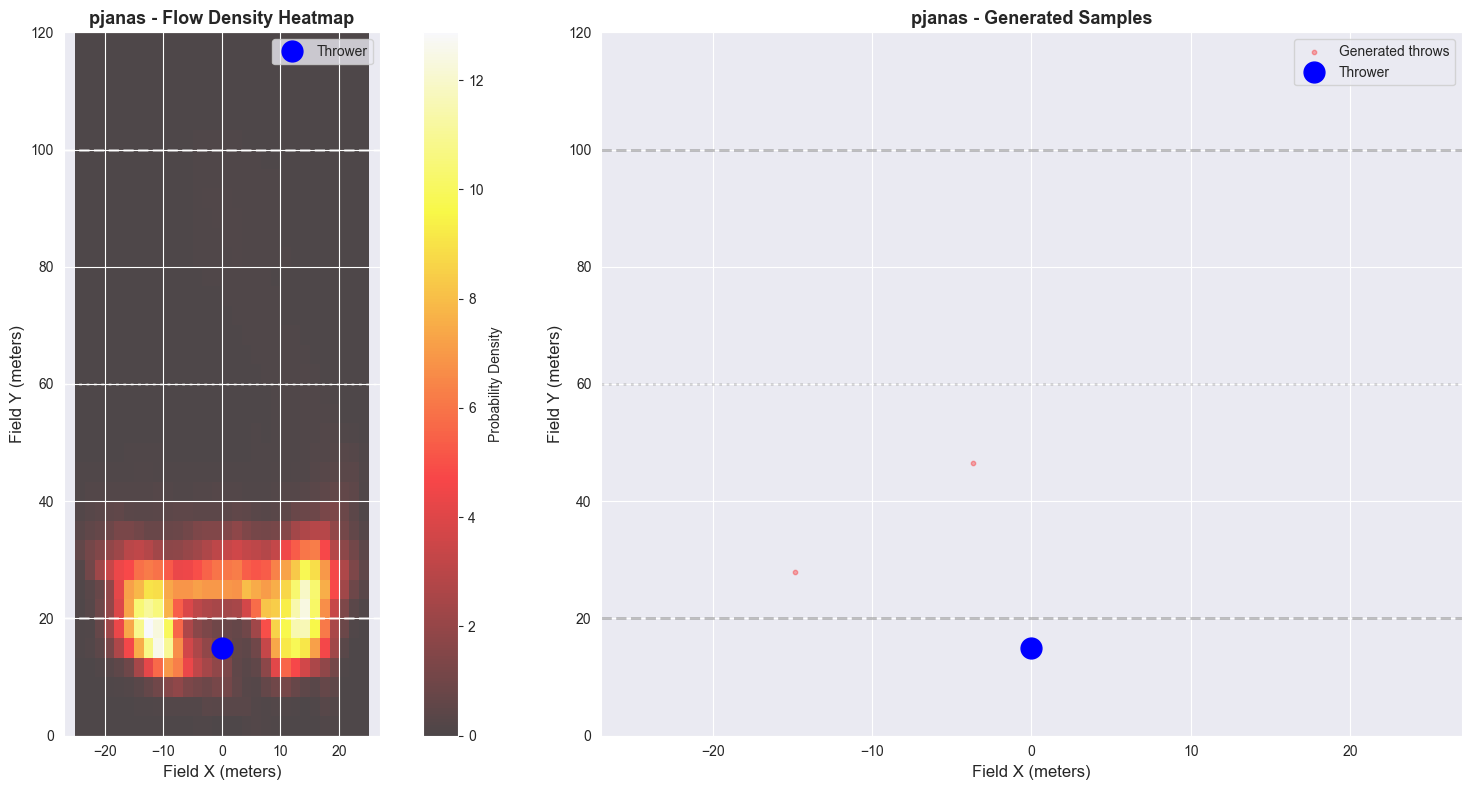

In [24]:
# From endzone
visualize_flow_prediction(top_player, thrower_x=0, thrower_y=15)

## 8. Save Model

In [25]:
# Save flow model
os.makedirs('models', exist_ok=True)

save_dict = {
    'flow_state_dict': flow.state_dict(),
    'context_net_state_dict': context_net.state_dict(),
    'player_encoder': player_encoder,
    'hyperparameters': {
        'n_players': n_players,
        'num_layers': NUM_LAYERS,
        'hidden_features': HIDDEN_FEATURES,
        'context_features': CONTEXT_FEATURES
    },
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss
}

joblib.dump(save_dict, 'models/normalizing_flow_model.pkl')
print("✅ Model saved to models/normalizing_flow_model.pkl")

✅ Model saved to models/normalizing_flow_model.pkl


## 9. Compare with MDN

**Normalizing Flow advantages:**
- ✅ Truly continuous distribution (no fixed K components)
- ✅ Exact likelihood computation
- ✅ Can generate realistic samples
- ✅ More flexible for complex patterns

**MDN advantages:**
- ✅ Faster training and inference
- ✅ More interpretable (can see K distinct throw options)
- ✅ Fewer parameters

**Expected performance:**
- Flow should achieve slightly better validation loss (e.g., -1.4 to -1.5 vs MDN's -1.3)
- Flow distributions should look smoother and more realistic
- Flow training takes ~2-3x longer

## Summary

This notebook implemented a **Conditional Normalizing Flow** for throw prediction:

1. ✅ Loaded throw data from PostgreSQL
2. ✅ Built Masked Autoregressive Flow (MAF) with player embeddings
3. ✅ Trained with negative log-likelihood loss
4. ✅ Generated continuous probability distributions
5. ✅ Visualized heatmaps and generated samples
6. ✅ Saved model for deployment

**Next steps:**
- Compare flow vs MDN performance quantitatively
- Integrate into web app (may want to use MDN for speed)
- Try more advanced flows (Neural Spline Flows, Residual Flows)